# Data Science Practice Workbook

This notebook contains practice data science work with a custom dataset and interactive filtering capabilities.

## Dataset Overview
- **Rows**: 12
- **Columns**: 3
  - `last name`: Random last names
  - `unit sf`: Unit square footage (integers divisible by 10, range 50-200)
  - `rental rate`: Rental rates (floats, range 50-250) with correlation to unit size

## Objectives
- Load and explore the dataset
- Perform basic data analysis
- Visualize relationships between variables
- Practice pandas and numpy operations
- **NEW**: Interactive filtering by unit size and rental rate


In [30]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print("Interactive widgets enabled for filtering!")


Libraries imported successfully!
Pandas version: 2.3.2
NumPy version: 2.3.3
Interactive widgets enabled for filtering!


In [31]:
# Load the practice dataset from CSV file
df = pd.read_csv('practice_dataset.csv')

# Display the dataset
print("Practice Dataset (Loaded from CSV):")
print("=" * 50)
print(df)

print(f"\nDataset Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Data Types:\n{df.dtypes}")

# Store original dataset for reference
df_original = df.copy()


Practice Dataset (Loaded from CSV):
    last name  unit sf  rental rate
0     Minsley       50        51.20
1        Neal       60        59.61
2    Hoffmann      100       110.33
3       Brown      190       211.58
4       Jones      180       198.02
5      Garcia      160       180.24
6      Miller      130       149.33
7       Davis      140       146.48
8   Rodriguez       70        76.14
9    Martinez      200       229.48
10  Hernandez       90       115.02
11      Lopez      120       132.43

Dataset Shape: (12, 3)
Columns: ['last name', 'unit sf', 'rental rate']
Data Types:
last name       object
unit sf          int64
rental rate    float64
dtype: object


## Interactive Data Filtering

Use the interactive filters below to explore the dataset by unit size and rental rate ranges.


In [32]:
# Define filtering function
def filter_data(min_unit_sf=50, max_unit_sf=200, min_rental_rate=50, max_rental_rate=250):
    """
    Filter the dataset based on unit size and rental rate ranges
    """
    # Apply filters
    filtered_df = df_original[
        (df_original['unit sf'] >= min_unit_sf) & 
        (df_original['unit sf'] <= max_unit_sf) &
        (df_original['rental rate'] >= min_rental_rate) & 
        (df_original['rental rate'] <= max_rental_rate)
    ].copy()
    
    # Display results
    print(f"Filtered Dataset ({len(filtered_df)} of {len(df_original)} units):")
    print("=" * 60)
    print(filtered_df)
    
    if len(filtered_df) > 0:
        print(f"\nFiltered Statistics:")
        print(f"Average unit size: {filtered_df['unit sf'].mean():.1f} sq ft")
        print(f"Average rental rate: ${filtered_df['rental rate'].mean():.2f}")
        print(f"Average rate per sq ft: ${(filtered_df['rental rate'] / filtered_df['unit sf']).mean():.2f}")
        
        # Show correlation for filtered data
        if len(filtered_df) > 1:
            correlation = filtered_df['unit sf'].corr(filtered_df['rental rate'])
            print(f"Correlation (unit sf vs rental rate): {correlation:.3f}")
    else:
        print("No units match the current filter criteria.")
    
    return filtered_df

# Create interactive widget
interact(
    filter_data,
    min_unit_sf=widgets.IntSlider(min=50, max=200, step=10, value=50, description='Min Unit SF:'),
    max_unit_sf=widgets.IntSlider(min=50, max=200, step=10, value=200, description='Max Unit SF:'),
    min_rental_rate=widgets.FloatSlider(min=50, max=250, step=5, value=50, description='Min Rental Rate:'),
    max_rental_rate=widgets.FloatSlider(min=50, max=250, step=5, value=250, description='Max Rental Rate:')
)


interactive(children=(IntSlider(value=50, description='Min Unit SF:', max=200, min=50, step=10), IntSlider(val…

<function __main__.filter_data(min_unit_sf=50, max_unit_sf=200, min_rental_rate=50, max_rental_rate=250)>

## Advanced Filtering Options

Try these preset filters or create custom combinations:


In [33]:
# Preset filter functions
def show_small_units():
    """Show units with 50-100 sq ft"""
    return filter_data(min_unit_sf=50, max_unit_sf=100, min_rental_rate=50, max_rental_rate=250)

def show_medium_units():
    """Show units with 101-150 sq ft"""
    return filter_data(min_unit_sf=101, max_unit_sf=150, min_rental_rate=50, max_rental_rate=250)

def show_large_units():
    """Show units with 151-200 sq ft"""
    return filter_data(min_unit_sf=151, max_unit_sf=200, min_rental_rate=50, max_rental_rate=250)

def show_budget_units():
    """Show units with rental rate $50-$125"""
    return filter_data(min_unit_sf=50, max_unit_sf=200, min_rental_rate=50, max_rental_rate=125)

def show_premium_units():
    """Show units with rental rate $175-$250"""
    return filter_data(min_unit_sf=50, max_unit_sf=200, min_rental_rate=175, max_rental_rate=250)

def show_best_value():
    """Show units with best rate per sq ft (lowest)"""
    df_temp = df_original.copy()
    df_temp['rate_per_sf'] = df_temp['rental rate'] / df_temp['unit sf']
    best_value = df_temp.nsmallest(3, 'rate_per_sf')
    print("Best Value Units (Lowest Rate per Sq Ft):")
    print("=" * 50)
    print(best_value[['last name', 'unit sf', 'rental rate', 'rate_per_sf']].round(2))
    return best_value

# Create buttons for preset filters
print("Quick Filter Buttons:")
print("=" * 30)

# Create interactive buttons
interact_manual(
    filter_preset=widgets.Dropdown(
        options=[
            ('All Units', 'all'),
            ('Small Units (50-100 sq ft)', 'small'),
            ('Medium Units (101-150 sq ft)', 'medium'),
            ('Large Units (151-200 sq ft)', 'large'),
            ('Budget Units ($50-$125)', 'budget'),
            ('Premium Units ($175-$250)', 'premium'),
            ('Best Value Units', 'best_value')
        ],
        description='Filter Preset:',
        value='all'
    )
)

def apply_preset_filter(filter_preset):
    if filter_preset == 'all':
        return filter_data(50, 200, 50, 250)
    elif filter_preset == 'small':
        return show_small_units()
    elif filter_preset == 'medium':
        return show_medium_units()
    elif filter_preset == 'large':
        return show_large_units()
    elif filter_preset == 'budget':
        return show_budget_units()
    elif filter_preset == 'premium':
        return show_premium_units()
    elif filter_preset == 'best_value':
        return show_best_value()

# Apply the preset filter function
interact(apply_preset_filter, filter_preset=widgets.Dropdown(
    options=[
        ('All Units', 'all'),
        ('Small Units (50-100 sq ft)', 'small'),
        ('Medium Units (101-150 sq ft)', 'medium'),
        ('Large Units (151-200 sq ft)', 'large'),
        ('Budget Units ($50-$125)', 'budget'),
        ('Premium Units ($175-$250)', 'premium'),
        ('Best Value Units', 'best_value')
    ],
    description='Filter Preset:',
    value='all'
))


Quick Filter Buttons:


interactive(children=(Dropdown(description='Filter Preset:', options=(('All Units', 'all'), ('Small Units (50-…

<function __main__.apply_preset_filter(filter_preset)>

## Data Analysis and Visualization

Now let's perform comprehensive analysis on the dataset:


In [34]:
# Basic data exploration and statistics
print("Basic Statistics:")
print("=" * 30)
print(df.describe())

print("\nMissing Values:")
print("=" * 20)
print(df.isnull().sum())

print("\nUnique Values:")
print("=" * 20)
print(f"Unique last names: {df['last name'].nunique()}")
print(f"Unique unit sizes: {df['unit sf'].nunique()}")
print(f"Unique rental rates: {df['rental rate'].nunique()}")

# Add rate per square foot column
df['rate_per_sf'] = df['rental rate'] / df['unit sf']


Basic Statistics:
          unit sf  rental rate
count   12.000000    12.000000
mean   124.166667   138.321667
std     51.426617    58.928993
min     50.000000    51.200000
25%     85.000000   101.782500
50%    125.000000   139.455000
75%    165.000000   184.685000
max    200.000000   229.480000

Missing Values:
last name      0
unit sf        0
rental rate    0
dtype: int64

Unique Values:
Unique last names: 12
Unique unit sizes: 12
Unique rental rates: 12


In [35]:
# Data analysis and insights
print("Data Analysis:")
print("=" * 20)

# Correlation between unit sf and rental rate
correlation = df['unit sf'].corr(df['rental rate'])
print(f"Correlation between unit sf and rental rate: {correlation:.3f}")

# Average rental rate per square foot
avg_rate_per_sf = df['rate_per_sf'].mean()
print(f"Average rental rate per square foot: ${avg_rate_per_sf:.2f}")

# Find the most and least expensive units
most_expensive = df.loc[df['rental rate'].idxmax()]
least_expensive = df.loc[df['rental rate'].idxmin()]

print(f"\nMost expensive unit: {most_expensive['last name']} - {most_expensive['unit sf']} sq ft - ${most_expensive['rental rate']}")
print(f"Least expensive unit: {least_expensive['last name']} - {least_expensive['unit sf']} sq ft - ${least_expensive['rental rate']}")

# Show the rate per square foot for each unit
print(f"\nRate per square foot for each unit:")
print(df[['last name', 'unit sf', 'rental rate', 'rate_per_sf']].round(2))


Data Analysis:
Correlation between unit sf and rental rate: 0.994
Average rental rate per square foot: $1.11

Most expensive unit: Martinez - 200 sq ft - $229.48
Least expensive unit: Minsley - 50 sq ft - $51.2

Rate per square foot for each unit:
    last name  unit sf  rental rate  rate_per_sf
0     Minsley       50        51.20         1.02
1        Neal       60        59.61         0.99
2    Hoffmann      100       110.33         1.10
3       Brown      190       211.58         1.11
4       Jones      180       198.02         1.10
5      Garcia      160       180.24         1.13
6      Miller      130       149.33         1.15
7       Davis      140       146.48         1.05
8   Rodriguez       70        76.14         1.09
9    Martinez      200       229.48         1.15
10  Hernandez       90       115.02         1.28
11      Lopez      120       132.43         1.10


In [36]:
# Interactive visualization with filtering
def create_filtered_visualization(min_unit_sf=50, max_unit_sf=200, min_rental_rate=50, max_rental_rate=250):
    """
    Create visualizations for filtered data
    """
    # Apply filters
    filtered_df = df_original[
        (df_original['unit sf'] >= min_unit_sf) & 
        (df_original['unit sf'] <= max_unit_sf) &
        (df_original['rental rate'] >= min_rental_rate) & 
        (df_original['rental rate'] <= max_rental_rate)
    ].copy()
    
    if len(filtered_df) == 0:
        print("No data to visualize with current filters.")
        return
    
    # Add rate per sq ft column
    filtered_df['rate_per_sf'] = filtered_df['rental rate'] / filtered_df['unit sf']
    
    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Filtered Data Analysis ({len(filtered_df)} units)', fontsize=16)
    
    # 1. Scatter plot: Unit SF vs Rental Rate
    axes[0, 0].scatter(filtered_df['unit sf'], filtered_df['rental rate'], alpha=0.7, s=100, color='blue')
    axes[0, 0].set_xlabel('Unit Square Footage')
    axes[0, 0].set_ylabel('Rental Rate ($)')
    axes[0, 0].set_title('Unit Size vs Rental Rate')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Add trend line if we have enough points
    if len(filtered_df) > 1:
        z = np.polyfit(filtered_df['unit sf'], filtered_df['rental rate'], 1)
        p = np.poly1d(z)
        axes[0, 0].plot(filtered_df['unit sf'], p(filtered_df['unit sf']), "r--", alpha=0.8)
    
    # 2. Histogram of rental rates
    axes[0, 1].hist(filtered_df['rental rate'], bins=min(6, len(filtered_df)), alpha=0.7, edgecolor='black', color='green')
    axes[0, 1].set_xlabel('Rental Rate ($)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Distribution of Rental Rates')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Histogram of unit sizes
    axes[1, 0].hist(filtered_df['unit sf'], bins=min(6, len(filtered_df)), alpha=0.7, edgecolor='black', color='orange')
    axes[1, 0].set_xlabel('Unit Square Footage')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Distribution of Unit Sizes')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Bar plot of rate per square foot
    axes[1, 1].bar(range(len(filtered_df)), filtered_df['rate_per_sf'], alpha=0.7, color='purple')
    axes[1, 1].set_xlabel('Unit Index')
    axes[1, 1].set_ylabel('Rate per Square Foot ($)')
    axes[1, 1].set_title('Rate per Square Foot by Unit')
    axes[1, 1].grid(True, alpha=0.3)
    
    # Add unit names to x-axis
    axes[1, 1].set_xticks(range(len(filtered_df)))
    axes[1, 1].set_xticklabels(filtered_df['last name'], rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\nFiltered Data Summary:")
    print(f"Units in range: {len(filtered_df)}")
    print(f"Average unit size: {filtered_df['unit sf'].mean():.1f} sq ft")
    print(f"Average rental rate: ${filtered_df['rental rate'].mean():.2f}")
    print(f"Average rate per sq ft: ${filtered_df['rate_per_sf'].mean():.2f}")
    if len(filtered_df) > 1:
        correlation = filtered_df['unit sf'].corr(filtered_df['rental rate'])
        print(f"Correlation: {correlation:.3f}")

# Create interactive visualization widget
interact(
    create_filtered_visualization,
    min_unit_sf=widgets.IntSlider(min=50, max=200, step=10, value=50, description='Min Unit SF:'),
    max_unit_sf=widgets.IntSlider(min=50, max=200, step=10, value=200, description='Max Unit SF:'),
    min_rental_rate=widgets.FloatSlider(min=50, max=250, step=5, value=50, description='Min Rental Rate:'),
    max_rental_rate=widgets.FloatSlider(min=50, max=250, step=5, value=250, description='Max Rental Rate:')
)


interactive(children=(IntSlider(value=50, description='Min Unit SF:', max=200, min=50, step=10), IntSlider(val…

<function __main__.create_filtered_visualization(min_unit_sf=50, max_unit_sf=200, min_rental_rate=50, max_rental_rate=250)>

In [37]:
# Advanced pandas operations and data manipulation
print("Advanced Data Operations:")
print("=" * 30)

# Sort by rental rate (descending)
print("Units sorted by rental rate (highest to lowest):")
print(df.sort_values('rental rate', ascending=False)[['last name', 'unit sf', 'rental rate']])

print("\n" + "="*50)

# Filter units with rental rate above average
avg_rental = df['rental rate'].mean()
above_avg = df[df['rental rate'] > avg_rental]
print(f"Units with rental rate above average (${avg_rental:.2f}):")
print(above_avg[['last name', 'unit sf', 'rental rate']])

print("\n" + "="*50)

# Group by unit size ranges
df['size_category'] = pd.cut(df['unit sf'], 
                           bins=[0, 100, 150, 200], 
                           labels=['Small (≤100)', 'Medium (101-150)', 'Large (151-200)'])

print("Average rental rate by size category:")
size_analysis = df.groupby('size_category')['rental rate'].agg(['count', 'mean', 'std']).round(2)
print(size_analysis)

print("\n" + "="*50)

# Summary statistics by size category
print("Detailed analysis by size category:")
for category in df['size_category'].unique():
    if pd.notna(category):
        subset = df[df['size_category'] == category]
        print(f"\n{category} units:")
        print(f"  Count: {len(subset)}")
        print(f"  Average rental rate: ${subset['rental rate'].mean():.2f}")
        print(f"  Average rate per sq ft: ${subset['rate_per_sf'].mean():.2f}")
        print(f"  Units: {', '.join(subset['last name'].tolist())}")


Advanced Data Operations:
Units sorted by rental rate (highest to lowest):
    last name  unit sf  rental rate
9    Martinez      200       229.48
3       Brown      190       211.58
4       Jones      180       198.02
5      Garcia      160       180.24
6      Miller      130       149.33
7       Davis      140       146.48
11      Lopez      120       132.43
10  Hernandez       90       115.02
2    Hoffmann      100       110.33
8   Rodriguez       70        76.14
1        Neal       60        59.61
0     Minsley       50        51.20

Units with rental rate above average ($138.32):
  last name  unit sf  rental rate
3     Brown      190       211.58
4     Jones      180       198.02
5    Garcia      160       180.24
6    Miller      130       149.33
7     Davis      140       146.48
9  Martinez      200       229.48

Average rental rate by size category:
                  count    mean    std
size_category                         
Small (≤100)          5   82.46  29.05
Medium (101-15

C:\Users\brad\AppData\Local\Temp\ipykernel_15372\87203665.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_analysis = df.groupby('size_category')['rental rate'].agg(['count', 'mean', 'std']).round(2)


## Practice Exercises with Filtering

Try these exercises to further practice your data science skills with the filtering capabilities:

1. **Custom Filtering**: Use the interactive sliders to find units in specific size and price ranges
2. **Preset Analysis**: Try the preset filters to analyze different market segments
3. **Visualization**: Use the interactive visualization to see how correlations change with different filters
4. **Statistical Analysis**: Calculate the median, mode, and range for filtered datasets
5. **Data Transformation**: Create new categories based on filtered data
6. **Correlation Analysis**: Compare correlations between filtered and unfiltered data
7. **Export Filtered Data**: Save filtered datasets to new CSV files

### Filtering Tips:
- **Small Units (50-100 sq ft)**: Look for budget-friendly options
- **Medium Units (101-150 sq ft)**: Find the sweet spot for value
- **Large Units (151-200 sq ft)**: Identify premium market segments
- **Budget Units ($50-$125)**: Analyze affordable housing options
- **Premium Units ($175-$250)**: Study high-end market characteristics
- **Best Value**: Find units with the lowest cost per square foot


In [38]:
# Export filtered data function
def export_filtered_data(min_unit_sf=50, max_unit_sf=200, min_rental_rate=50, max_rental_rate=250, filename="filtered_data.csv"):
    """
    Export filtered data to CSV file
    """
    # Apply filters
    filtered_df = df_original[
        (df_original['unit sf'] >= min_unit_sf) & 
        (df_original['unit sf'] <= max_unit_sf) &
        (df_original['rental rate'] >= min_rental_rate) & 
        (df_original['rental rate'] <= max_rental_rate)
    ].copy()
    
    if len(filtered_df) > 0:
        # Add calculated columns
        filtered_df['rate_per_sf'] = filtered_df['rental rate'] / filtered_df['unit sf']
        filtered_df['size_category'] = pd.cut(filtered_df['unit sf'], 
                                            bins=[0, 100, 150, 200], 
                                            labels=['Small', 'Medium', 'Large'])
        
        # Save to CSV
        filtered_df.to_csv(filename, index=False)
        print(f"Filtered data exported to {filename}")
        print(f"Exported {len(filtered_df)} units")
        print(f"Filter criteria: Unit SF {min_unit_sf}-{max_unit_sf}, Rental Rate ${min_rental_rate}-${max_rental_rate}")
        return filtered_df
    else:
        print("No data to export with current filter criteria.")
        return None

# Interactive export widget
interact(
    export_filtered_data,
    min_unit_sf=widgets.IntSlider(min=50, max=200, step=10, value=50, description='Min Unit SF:'),
    max_unit_sf=widgets.IntSlider(min=50, max=200, step=10, value=200, description='Max Unit SF:'),
    min_rental_rate=widgets.FloatSlider(min=50, max=250, step=5, value=50, description='Min Rental Rate:'),
    max_rental_rate=widgets.FloatSlider(min=50, max=250, step=5, value=250, description='Max Rental Rate:'),
    filename=widgets.Text(value='filtered_data.csv', description='Filename:')
)


interactive(children=(IntSlider(value=50, description='Min Unit SF:', max=200, min=50, step=10), IntSlider(val…

<function __main__.export_filtered_data(min_unit_sf=50, max_unit_sf=200, min_rental_rate=50, max_rental_rate=250, filename='filtered_data.csv')>

# Data Science Practice Workbook

This notebook contains practice data science work with a custom dataset.

## Dataset Overview
- **Rows**: 12
- **Columns**: 3
  - `last name`: Random last names
  - `unit sf`: Unit square footage (integers divisible by 10, range 50-200)
  - `rental rate`: Rental rates (floats, range 50-250) with correlation to unit size

## Objectives
- Load and explore the dataset
- Perform basic data analysis
- Visualize relationships between variables
- Practice pandas and numpy operations


In [39]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from create_dataset import create_practice_dataset

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")


Libraries imported successfully!
Pandas version: 2.3.2
NumPy version: 2.3.3


In [40]:
# Create and load the practice dataset
df = create_practice_dataset()

# Display the dataset
print("Practice Dataset:")
print("=" * 50)
print(df)

print(f"\nDataset Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Data Types:\n{df.dtypes}")


Practice Dataset:
    last name  unit sf  rental rate
0       Smith       50        51.20
1     Johnson       60        59.61
2    Williams      100       110.33
3       Brown      190       211.58
4       Jones      180       198.02
5      Garcia      160       180.24
6      Miller      130       149.33
7       Davis      140       146.48
8   Rodriguez       70        76.14
9    Martinez      200       229.48
10  Hernandez       90       115.02
11      Lopez      120       132.43

Dataset Shape: (12, 3)
Columns: ['last name', 'unit sf', 'rental rate']
Data Types:
last name       object
unit sf          int64
rental rate    float64
dtype: object


In [41]:
# Basic data exploration and statistics
print("Basic Statistics:")
print("=" * 30)
print(df.describe())

print("\nMissing Values:")
print("=" * 20)
print(df.isnull().sum())

print("\nUnique Values:")
print("=" * 20)
print(f"Unique last names: {df['last name'].nunique()}")
print(f"Unique unit sizes: {df['unit sf'].nunique()}")
print(f"Unique rental rates: {df['rental rate'].nunique()}")


Basic Statistics:
          unit sf  rental rate
count   12.000000    12.000000
mean   124.166667   138.321667
std     51.426617    58.928993
min     50.000000    51.200000
25%     85.000000   101.782500
50%    125.000000   139.455000
75%    165.000000   184.685000
max    200.000000   229.480000

Missing Values:
last name      0
unit sf        0
rental rate    0
dtype: int64

Unique Values:
Unique last names: 12
Unique unit sizes: 12
Unique rental rates: 12


In [42]:
# Data analysis and insights
print("Data Analysis:")
print("=" * 20)

# Correlation between unit sf and rental rate
correlation = df['unit sf'].corr(df['rental rate'])
print(f"Correlation between unit sf and rental rate: {correlation:.3f}")

# Average rental rate per square foot
df['rate_per_sf'] = df['rental rate'] / df['unit sf']
avg_rate_per_sf = df['rate_per_sf'].mean()
print(f"Average rental rate per square foot: ${avg_rate_per_sf:.2f}")

# Find the most and least expensive units
most_expensive = df.loc[df['rental rate'].idxmax()]
least_expensive = df.loc[df['rental rate'].idxmin()]

print(f"\nMost expensive unit: {most_expensive['last name']} - {most_expensive['unit sf']} sq ft - ${most_expensive['rental rate']}")
print(f"Least expensive unit: {least_expensive['last name']} - {least_expensive['unit sf']} sq ft - ${least_expensive['rental rate']}")

# Show the rate per square foot for each unit
print(f"\nRate per square foot for each unit:")
print(df[['last name', 'unit sf', 'rental rate', 'rate_per_sf']].round(2))


Data Analysis:
Correlation between unit sf and rental rate: 0.994
Average rental rate per square foot: $1.11

Most expensive unit: Martinez - 200 sq ft - $229.48
Least expensive unit: Smith - 50 sq ft - $51.2

Rate per square foot for each unit:
    last name  unit sf  rental rate  rate_per_sf
0       Smith       50        51.20         1.02
1     Johnson       60        59.61         0.99
2    Williams      100       110.33         1.10
3       Brown      190       211.58         1.11
4       Jones      180       198.02         1.10
5      Garcia      160       180.24         1.13
6      Miller      130       149.33         1.15
7       Davis      140       146.48         1.05
8   Rodriguez       70        76.14         1.09
9    Martinez      200       229.48         1.15
10  Hernandez       90       115.02         1.28
11      Lopez      120       132.43         1.10


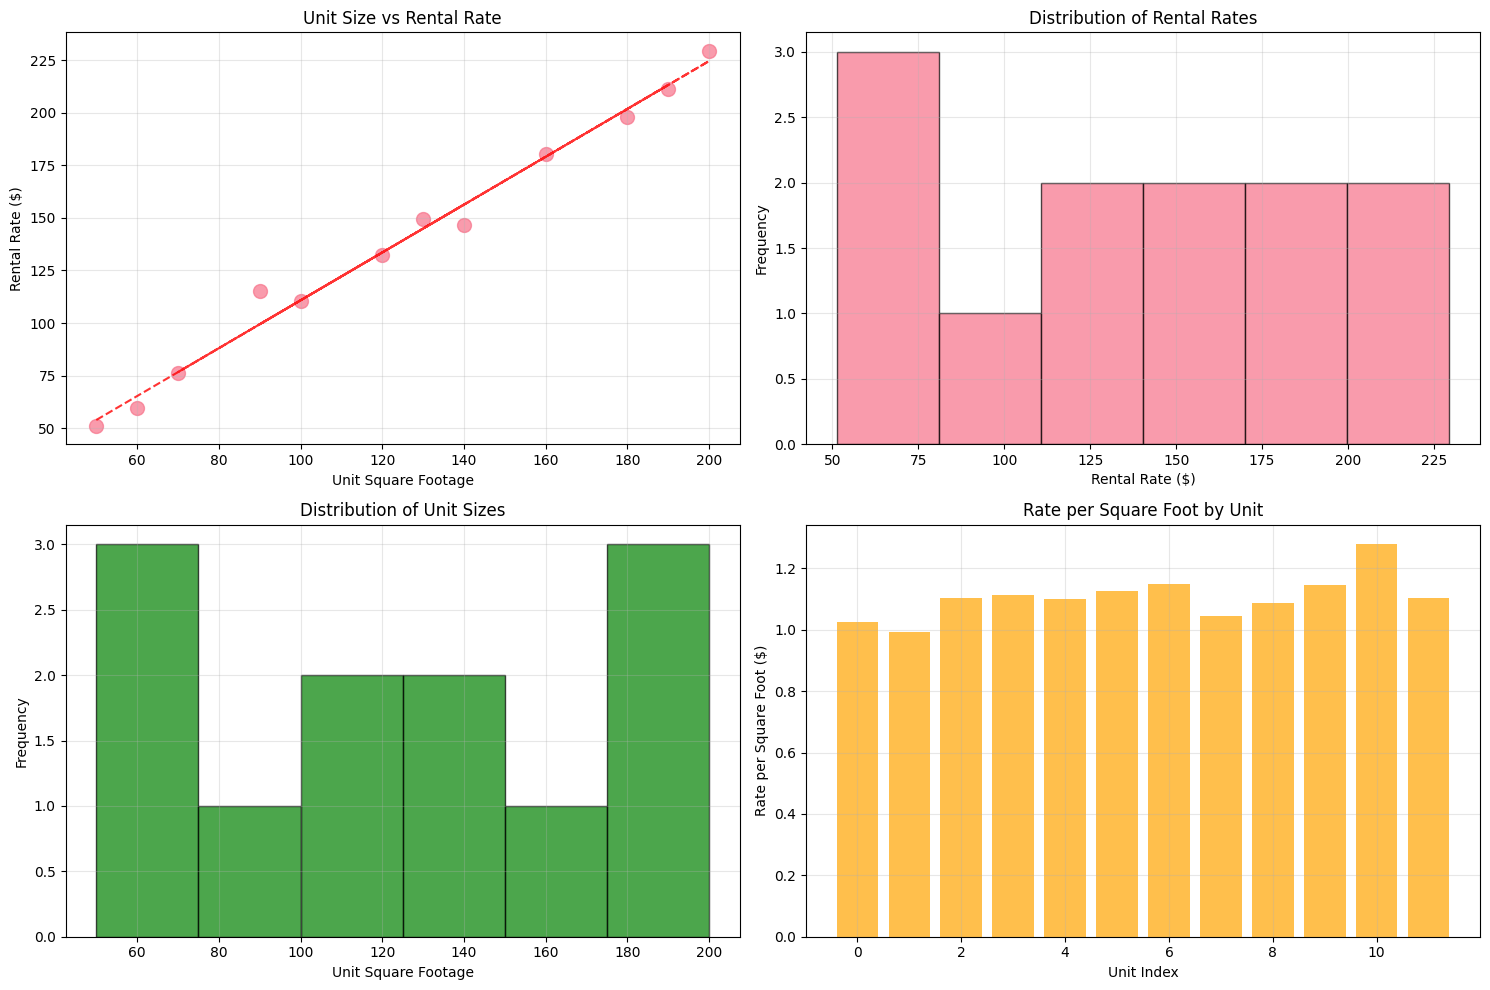

In [43]:
# Data visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Scatter plot: Unit SF vs Rental Rate
axes[0, 0].scatter(df['unit sf'], df['rental rate'], alpha=0.7, s=100)
axes[0, 0].set_xlabel('Unit Square Footage')
axes[0, 0].set_ylabel('Rental Rate ($)')
axes[0, 0].set_title('Unit Size vs Rental Rate')
axes[0, 0].grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(df['unit sf'], df['rental rate'], 1)
p = np.poly1d(z)
axes[0, 0].plot(df['unit sf'], p(df['unit sf']), "r--", alpha=0.8)

# 2. Histogram of rental rates
axes[0, 1].hist(df['rental rate'], bins=6, alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Rental Rate ($)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Rental Rates')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histogram of unit sizes
axes[1, 0].hist(df['unit sf'], bins=6, alpha=0.7, edgecolor='black', color='green')
axes[1, 0].set_xlabel('Unit Square Footage')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Unit Sizes')
axes[1, 0].grid(True, alpha=0.3)

# 4. Bar plot of rate per square foot
axes[1, 1].bar(range(len(df)), df['rate_per_sf'], alpha=0.7, color='orange')
axes[1, 1].set_xlabel('Unit Index')
axes[1, 1].set_ylabel('Rate per Square Foot ($)')
axes[1, 1].set_title('Rate per Square Foot by Unit')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [24]:
# Advanced pandas operations and data manipulation
print("Advanced Data Operations:")
print("=" * 30)

# Sort by rental rate (descending)
print("Units sorted by rental rate (highest to lowest):")
print(df.sort_values('rental rate', ascending=False)[['last name', 'unit sf', 'rental rate']])

print("\n" + "="*50)

# Filter units with rental rate above average
avg_rental = df['rental rate'].mean()
above_avg = df[df['rental rate'] > avg_rental]
print(f"Units with rental rate above average (${avg_rental:.2f}):")
print(above_avg[['last name', 'unit sf', 'rental rate']])

print("\n" + "="*50)

# Group by unit size ranges
df['size_category'] = pd.cut(df['unit sf'], 
                           bins=[0, 100, 150, 200], 
                           labels=['Small (≤100)', 'Medium (101-150)', 'Large (151-200)'])

print("Average rental rate by size category:")
size_analysis = df.groupby('size_category')['rental rate'].agg(['count', 'mean', 'std']).round(2)
print(size_analysis)

print("\n" + "="*50)

# Summary statistics by size category
print("Detailed analysis by size category:")
for category in df['size_category'].unique():
    if pd.notna(category):
        subset = df[df['size_category'] == category]
        print(f"\n{category} units:")
        print(f"  Count: {len(subset)}")
        print(f"  Average rental rate: ${subset['rental rate'].mean():.2f}")
        print(f"  Average rate per sq ft: ${subset['rate_per_sf'].mean():.2f}")
        print(f"  Units: {', '.join(subset['last name'].tolist())}")


Advanced Data Operations:
Units sorted by rental rate (highest to lowest):
    last name  unit sf  rental rate
9    Martinez      200       229.48
3       Brown      190       211.58
4       Jones      180       198.02
5      Garcia      160       180.24
6      Miller      130       149.33
7       Davis      140       146.48
11      Lopez      120       132.43
10  Hernandez       90       115.02
2    Williams      100       110.33
8   Rodriguez       70        76.14
1     Johnson       60        59.61
0       Smith       50        51.20

Units with rental rate above average ($138.32):
  last name  unit sf  rental rate
3     Brown      190       211.58
4     Jones      180       198.02
5    Garcia      160       180.24
6    Miller      130       149.33
7     Davis      140       146.48
9  Martinez      200       229.48

Average rental rate by size category:
                  count    mean    std
size_category                         
Small (≤100)          5   82.46  29.05
Medium (101-15

C:\Users\brad\AppData\Local\Temp\ipykernel_15372\87203665.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_analysis = df.groupby('size_category')['rental rate'].agg(['count', 'mean', 'std']).round(2)


## Practice Exercises

Try these exercises to further practice your data science skills:

1. **Data Filtering**: Find all units with rental rates between $100 and $200
2. **Statistical Analysis**: Calculate the median, mode, and range for each numerical column
3. **Data Transformation**: Create a new column that categorizes units as "Budget", "Standard", or "Premium" based on rental rate
4. **Correlation Analysis**: Calculate the correlation matrix for all numerical columns
5. **Data Export**: Save the modified dataset to a new CSV file

### Additional NumPy Practice
- Use NumPy to calculate the standard deviation of rental rates
- Create a NumPy array from the unit sf column and perform mathematical operations
- Use NumPy's random functions to generate additional sample data
